# Data Insegtion

In [1]:
import pandas as pd

df1 = pd.read_excel(r"Data\\online_retail_II.xlsx", sheet_name="Year 2009-2010")
df1.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [2]:
df2 = pd.read_excel(r"Data\\online_retail_II.xlsx", sheet_name="Year 2010-2011")
df2.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [3]:
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

df1 shape: (525461, 8)
df2 shape: (541910, 8)


In [4]:
df = pd.concat([df1, df2], axis=0)
print("Combined df shape:", df.shape, "\n")
df.head(3)

Combined df shape: (1067371, 8) 



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


In [6]:
df.drop(columns=["Customer ID", "InvoiceDate"]).describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


In [7]:
df_cleaning = df.copy()

# Data Cleaning

In [8]:
#Null Values
print("Before Drop Null")
print(f"Null Values: {df.isnull().sum()}")
print(df.shape)

print("\nAfter Drop Null")
df_cleaning.dropna(inplace=True, subset=["Customer ID"])
print(f"Null Values: {df_cleaning.isnull().sum()}")
print(df_cleaning.shape)

Before Drop Null
Null Values: Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
(1067371, 8)

After Drop Null
Null Values: Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
(824364, 8)


In [9]:
#Duplicate Values
print("Before Drop Duplicate")
print(df.duplicated().sum())

print("\nAfter Drop Duplicate")
df_cleaning.drop_duplicates(inplace=True)
print(df_cleaning.duplicated().sum())

Before Drop Duplicate
34335

After Drop Duplicate
0


In [10]:
#Change Data Type
df_cleaning["InvoiceDate"] = pd.to_datetime(df_cleaning["InvoiceDate"])
df_cleaning

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [11]:
print("Invalid values Before Cleaning: ")
print(f"Quantity <= 0: {df_cleaning[df_cleaning['Quantity'] <= 0].shape[0]}")
print(f"Price <= 0: {df_cleaning[df_cleaning['Price'] <= 0].shape[0]}")

print("\nInvalid values After Cleaning: ")

df_cleaning = df_cleaning[(df_cleaning['Quantity'] > 0) & (df_cleaning['Price'] > 0)]
print(f"Quantity <= 0: {df_cleaning[df_cleaning['Quantity'] <= 0].shape[0]}")
print(f"Price <= 0: {df_cleaning[df_cleaning['Price'] <= 0].shape[0]}")

Invalid values Before Cleaning: 
Quantity <= 0: 18390
Price <= 0: 70

Invalid values After Cleaning: 
Quantity <= 0: 0
Price <= 0: 0


# User Retention w/ cohort analysis

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
import os

In [13]:
cohort_df = df_cleaning[["Customer ID", "InvoiceDate"]].copy()
cohort_df["OrderMonth"] = cohort_df["InvoiceDate"].dt.to_period("M")
cohort_df["CohortMonth"] = (
    cohort_df.groupby("Customer ID")["InvoiceDate"].transform("min").dt.to_period("M")
)

cohort_df

,Customer ID,InvoiceDate,OrderMonth,CohortMonth
0,13085.0,2009-12-01 07:45:00,2009-12,2009-12
1,13085.0,2009-12-01 07:45:00,2009-12,2009-12
2,13085.0,2009-12-01 07:45:00,2009-12,2009-12
3,13085.0,2009-12-01 07:45:00,2009-12,2009-12
4,13085.0,2009-12-01 07:45:00,2009-12,2009-12
...,...,...,...,...
541905,12680.0,2011-12-09 12:50:00,2011-12,2011-08
541906,12680.0,2011-12-09 12:50:00,2011-12,2011-08
541907,12680.0,2011-12-09 12:50:00,2011-12,2011-08
541908,12680.0,2011-12-09 12:50:00,2011-12,2011-08


In [14]:
cohort_df["CohortIndex"] = (
    (cohort_df["OrderMonth"].dt.year - cohort_df["CohortMonth"].dt.year) * 12
    + (cohort_df["OrderMonth"].dt.month - cohort_df["CohortMonth"].dt.month)
)

cohort_df

,Customer ID,InvoiceDate,OrderMonth,CohortMonth,CohortIndex
0,13085.0,2009-12-01 07:45:00,2009-12,2009-12,0
1,13085.0,2009-12-01 07:45:00,2009-12,2009-12,0
2,13085.0,2009-12-01 07:45:00,2009-12,2009-12,0
3,13085.0,2009-12-01 07:45:00,2009-12,2009-12,0
4,13085.0,2009-12-01 07:45:00,2009-12,2009-12,0
...,...,...,...,...,...
541905,12680.0,2011-12-09 12:50:00,2011-12,2011-08,4
541906,12680.0,2011-12-09 12:50:00,2011-12,2011-08,4
541907,12680.0,2011-12-09 12:50:00,2011-12,2011-08,4
541908,12680.0,2011-12-09 12:50:00,2011-12,2011-08,4


In [15]:
cohort_counts = (
    cohort_df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
    .nunique()
    .unstack()
)

cohort_counts

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
cohort_size = cohort_counts[0]
user_retention = cohort_counts.divide(cohort_size, axis=0).round(3)
user_retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126,0.059,0.083,...,0.126,0.138,0.165,0.154,0.047,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.126,0.089,0.081,0.119,...,0.122,0.133,0.204,0.052,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.140,0.113,0.145,0.145,0.113,...,0.172,0.237,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.173,0.117,0.099,0.123,0.136,0.130,...,0.198,0.068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


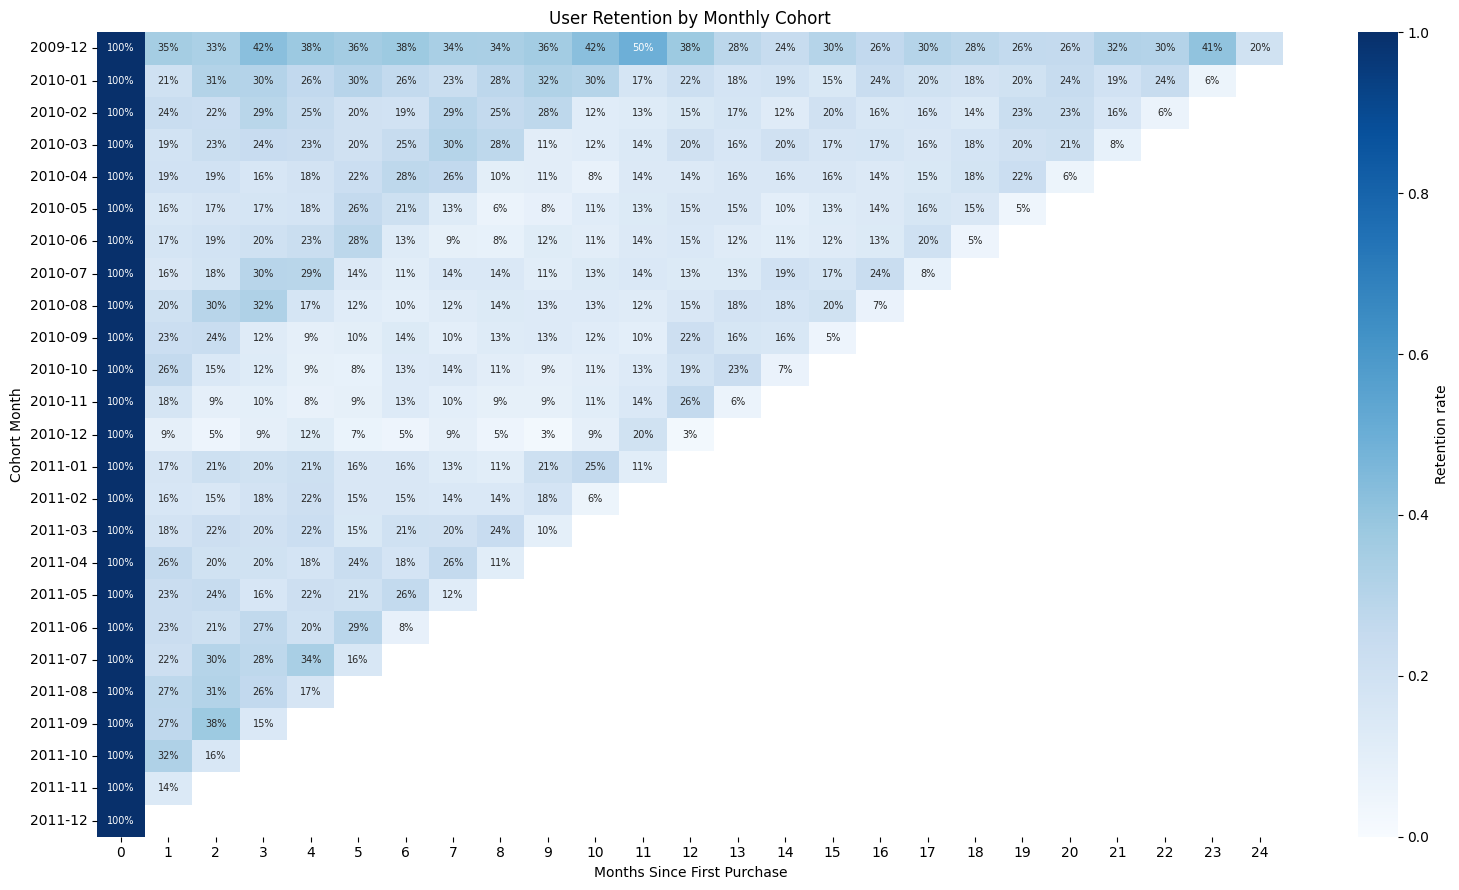

In [17]:
plt.figure(figsize=(16, 9))
sns.heatmap(
    user_retention,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    vmin=0, vmax=1,
    annot_kws={"size": 7},
    cbar_kws={"label": "Retention rate"},
)
plt.title("User Retention by Monthly Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()

plt.savefig("image/user_retention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Customer Segmentation

In [18]:
df_cleaning["TotalAmount"] = df_cleaning["Quantity"] * df_cleaning["Price"]
snapshot_date = df_cleaning["InvoiceDate"].max() + pd.Timedelta(days=1)

C:\Users\USER\AppData\Local\Temp\ipykernel_13088\700332829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning["TotalAmount"] = df_cleaning["Quantity"] * df_cleaning["Price"]


In [19]:
rfm = df_cleaning.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum"),
).reset_index()

rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


In [20]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


In [21]:
rfm["FM_Score"] = np.floor((rfm["F_Score"] + rfm["M_Score"]) / 2 + 0.5).astype(int)
rfm["FM_Score"].value_counts().sort_index()

FM_Score
1     672
2    1385
3    1223
4    1233
5    1365
Name: count, dtype: int64

In [22]:
segments = {
    "Champions":           (5, 5, 4, 5),
    "Loyal Customers":     (3, 4, 4, 5),
    "Potential Loyalist":  (4, 5, 2, 3),
    "New Customers":       (5, 5, 1, 1),
    "Promising":           (4, 4, 1, 1),
    "Need Attention":      (3, 3, 3, 3),
    "About to Sleep":      (3, 3, 1, 2),
    "Can't lose them":     (1, 2, 5, 5),
    "At Risk":             (1, 2, 3, 4),
    "Hibernating":         (1, 2, 1, 2),
}

def assign_segment(row):
    for name, (r0, r1, f0, f1) in segments.items():
        if r0 <= row["R_Score"] <= r1 and f0 <= row["FM_Score"] <= f1:
            return name
    return "Unassigned"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
rfm["Segment"].value_counts()

Segment
Hibernating           1376
Loyal Customers       1271
Champions              882
At Risk                865
Potential Loyalist     687
About to Sleep         317
Need Attention         277
Can't lose them        106
Promising               70
New Customers           27
Name: count, dtype: int64

In [23]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Monetary=("Monetary", "sum"),
).round(1).sort_values("Customers", ascending=False)

segment_summary["Pct_Customers"] = (
    segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
).round(1)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Pct_Customers
Segment,,,,,,
Hibernating,1376,465.8,1.2,279.8,384981.3,23.4
Loyal Customers,1271,67.7,9.2,4058.3,5158127.7,21.6
Champions,882,8.6,18.5,10430.6,9199775.6,15.0
At Risk,865,378.1,3.4,1255.0,1085614.0,14.7
Potential Loyalist,687,26.3,2.4,616.3,423374.8,11.7
About to Sleep,317,109.5,1.3,319.9,101396.2,5.4
Need Attention,277,109.9,2.9,838.4,232243.1,4.7
Can't lose them,106,336.9,12.6,7294.5,773215.7,1.8
Promising,70,37.7,1.0,162.3,11360.5,1.2


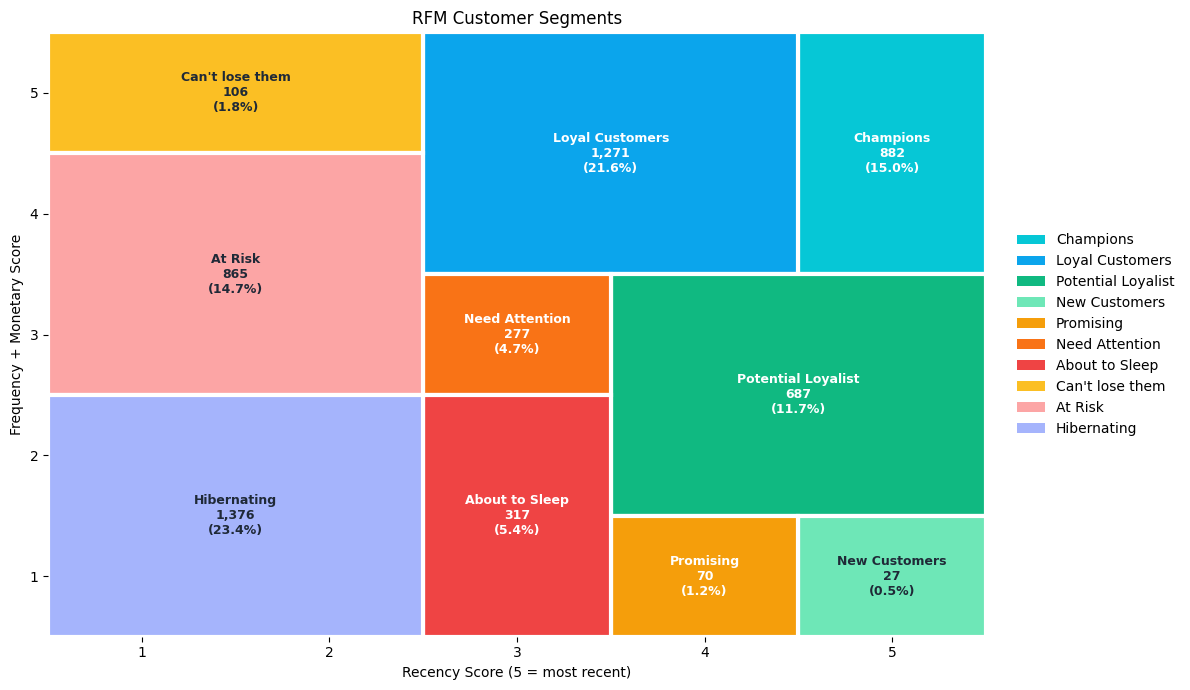

In [24]:
colors = {
    "Champions": "#06C7D6", "Loyal Customers": "#0BA5EC",
    "Potential Loyalist": "#10B981", "New Customers": "#6EE7B7",
    "Promising": "#F59E0B", "Need Attention": "#F97316",
    "About to Sleep": "#EF4444", "Can't lose them": "#FBBF24",
    "At Risk": "#FCA5A5", "Hibernating": "#A5B4FC",
}
dark_text = {"At Risk", "Hibernating", "New Customers", "Can't lose them"}

counts = rfm["Segment"].value_counts()
total = counts.sum()

fig, ax = plt.subplots(figsize=(12, 7))
for name, (r0, r1, f0, f1) in segments.items():
    ax.add_patch(Rectangle(
        (r0 - 0.5, f0 - 0.5), r1 - r0 + 1, f1 - f0 + 1,
        facecolor=colors[name], edgecolor="white", linewidth=3,
    ))
    n = counts.get(name, 0)
    ax.text(
        (r0 + r1) / 2, (f0 + f1) / 2,
        f"{name}\n{n:,}\n({n / total:.1%})",
        ha="center", va="center", fontsize=9, fontweight="bold",
        color="#1f2937" if name in dark_text else "white",
    )

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_xlabel("Recency Score (5 = most recent)")
ax.set_ylabel("Frequency + Monetary Score")
ax.set_title("RFM Customer Segments")
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    handles=[Patch(facecolor=colors[n], label=n) for n in segments],
    loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False,
)
plt.tight_layout()

plt.savefig("image/rfm_segments.png", dpi=300, bbox_inches="tight")
plt.show()

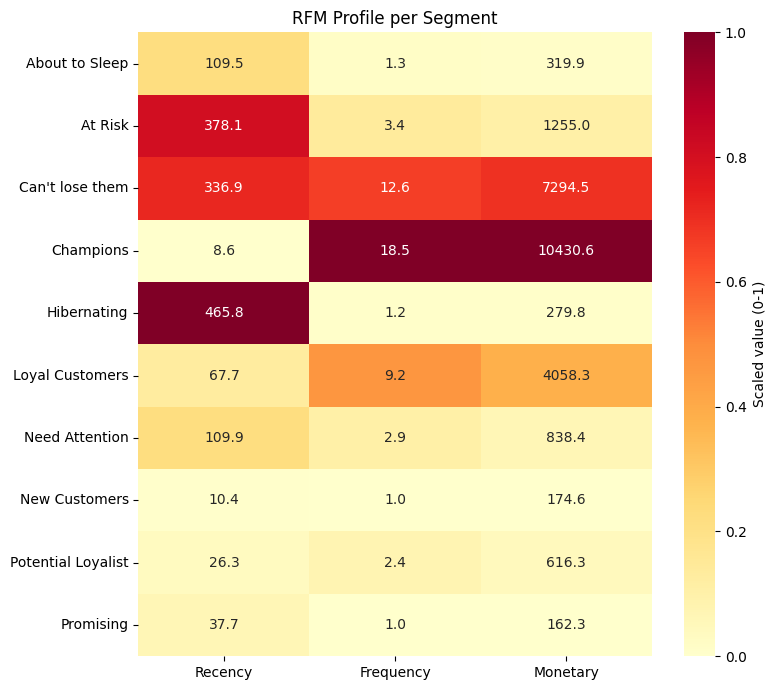

In [25]:
profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()
profile_scaled = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(8, 7))
sns.heatmap(profile_scaled, annot=profile.round(1), fmt="", cmap="YlOrRd",
            cbar_kws={"label": "Scaled value (0-1)"})
plt.title("RFM Profile per Segment")
plt.ylabel("")
plt.tight_layout()

plt.savefig("image/rfm_profile_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()